# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.

## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [19]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [20]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [21]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [22]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    X_train = np.loadtxt(f"{root_dir}/train/X_train.txt", dtype=np.float32)
    # 2. Load y_train from train/y_train.txt
    y_train = np.loadtxt(f"{root_dir}/train/y_train.txt", dtype=np.int32)
    # 3. Load X_test from test/X_test.txt
    X_test  = np.loadtxt(f"{root_dir}/test/X_test.txt",   dtype=np.float32)
    # 4. Load y_test from test/y_test.txt
    y_test  = np.loadtxt(f"{root_dir}/test/y_test.txt",   dtype=np.int32)
    # 5. Convert the labels to zero-based class indices by subtracting 1
    y_train = y_train - 1
    y_test  = y_test  - 1

    return X_train, y_train, X_test, y_test
    # <-- Enter your code here <--#
    raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
num_features = X_train.shape[1]
num_classes  = len(class_names)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("num_features: ", num_features)
print("num_classes:  ", num_classes)

X_train shape: (7352, 561)
X_test shape:  (2947, 561)
num_features:  561
num_classes:   6


## 5. Quick Inspection


In [23]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

label_counts = pd.Series(y_train).value_counts().sort_index()

pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name":  class_names,
    "Training Samples": label_counts.values
})

,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [24]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.
  
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model
    raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 256)               143872    
                                                                 
 dense_9 (Dense)             (None, 128)               32896     
                                                                 
 dense_10 (Dense)            (None, 64)                8256      
                                                                 
 dense_11 (Dense)            (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [25]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/40
92/92 [==============================] - 1s 3ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves


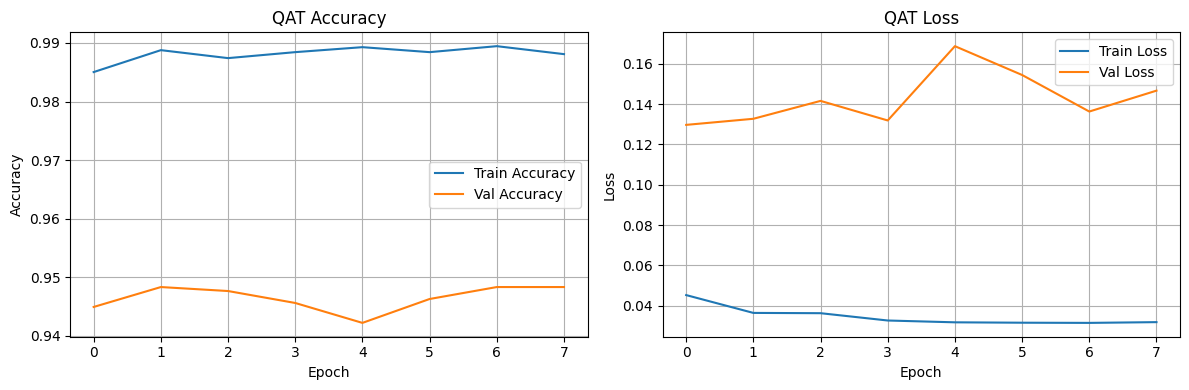

In [26]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(qat_history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(qat_history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("QAT Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(qat_history.history["loss"],     label="Train Loss")
axes[1].plot(qat_history.history["val_loss"], label="Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("QAT Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


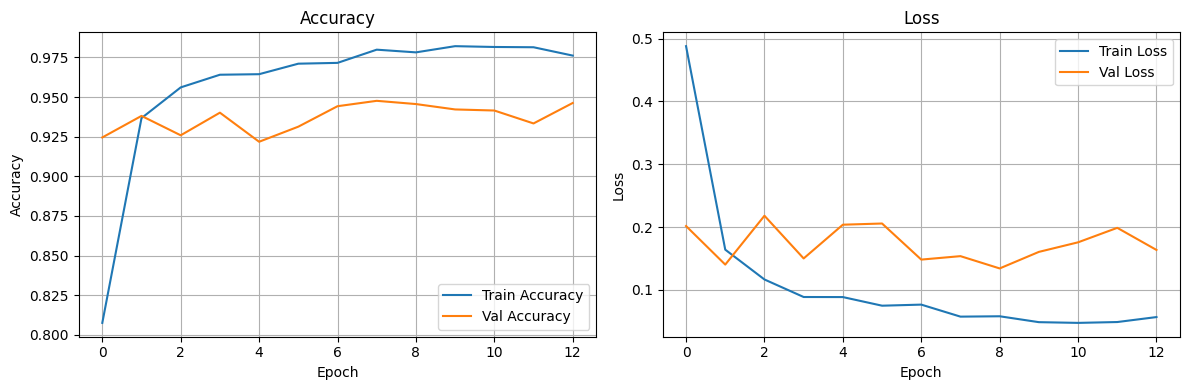

In [27]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [28]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])
        # <-- Enter your code here <--#
        # TODO:
        # If the output is quantized, dequantize it back to float32.
        
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    
    return converter.convert() 

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.
    
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model
    
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()

## 9. Post-Training Quantization (PTQ)


In [30]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
fp32_tflite = convert_to_tflite_fp32(baseline_model)
fp32_size_kb = save_binary_model(fp32_tflite, "baseline_fp32.tflite")
fp32_acc, _ = evaluate_tflite_model(fp32_tflite, X_test, y_test)
# - dynamic range TFLite
dynamic_tflite = convert_to_tflite_dynamic_range(baseline_model)
dynamic_size_kb = save_binary_model(dynamic_tflite, "baseline_dynamic.tflite")
dynamic_acc, _ = evaluate_tflite_model(dynamic_tflite, X_test, y_test)
# - float16 TFLite
float16_tflite = convert_to_tflite_float16(baseline_model)
float16_size_kb = save_binary_model(float16_tflite, "baseline_float16.tflite")
float16_acc, _ = evaluate_tflite_model(float16_tflite, X_test, y_test)
# - int8 TFLite
int8_tflite = convert_to_tflite_int8(baseline_model)
int8_size_kb = save_binary_model(int8_tflite, "baseline_int8.tflite")
int8_acc, _ = evaluate_tflite_model(int8_tflite, X_test, y_test)

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.
print(f"FP32:          {fp32_acc:.4f} accuracy, {fp32_size_kb:.2f} KB")
print(f"Dynamic Range: {dynamic_acc:.4f} accuracy, {dynamic_size_kb:.2f} KB")
print(f"Float16:       {float16_acc:.4f} accuracy, {float16_size_kb:.2f} KB")
print(f"Int8:          {int8_acc:.4f} accuracy, {int8_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpe2229d7b/assets


INFO:tensorflow:Assets written to: /tmp/tmpe2229d7b/assets
2026-04-23 04:51:09.320852: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 04:51:09.320880: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 04:51:09.321025: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpe2229d7b
2026-04-23 04:51:09.321662: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 04:51:09.321670: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpe2229d7b
2026-04-23 04:51:09.323541: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 04:51:09.346860: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpe2229d7b
2026-04-23 04:51:09.353027: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpzgf5zub1/assets


INFO:tensorflow:Assets written to: /tmp/tmpzgf5zub1/assets
2026-04-23 04:51:09.693436: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 04:51:09.693462: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 04:51:09.693572: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpzgf5zub1
2026-04-23 04:51:09.694019: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 04:51:09.694026: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpzgf5zub1
2026-04-23 04:51:09.695425: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 04:51:09.718304: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpzgf5zub1
2026-04-23 04:51:09.724390: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp6npno4rg/assets


INFO:tensorflow:Assets written to: /tmp/tmp6npno4rg/assets
2026-04-23 04:51:10.060629: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 04:51:10.060657: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 04:51:10.060757: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp6npno4rg
2026-04-23 04:51:10.061286: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 04:51:10.061294: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp6npno4rg
2026-04-23 04:51:10.063266: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 04:51:10.086883: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp6npno4rg
2026-04-23 04:51:10.093007: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp6kjwl1lu/assets


INFO:tensorflow:Assets written to: /tmp/tmp6kjwl1lu/assets
/home/sam/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 04:51:10.439354: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 04:51:10.439381: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 04:51:10.439479: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp6kjwl1lu
2026-04-23 04:51:10.440022: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 04:51:10.440033: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp6kjwl1lu
2026-04-23 04:51:10.442085: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-

FP32:          0.9220 accuracy, 726.77 KB
Dynamic Range: 0.9213 accuracy, 186.17 KB
Float16:       0.9220 accuracy, 365.80 KB
Int8:          0.9220 accuracy, 185.39 KB


## 10. PTQ Comparison: Accuracy and Model Size


In [31]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

ptq_results = pd.DataFrame([
    ["Baseline DNN", "FP32",          fp32_acc,     fp32_size_kb],
    ["Baseline DNN", "Dynamic Range", dynamic_acc,  dynamic_size_kb],
    ["Baseline DNN", "Float16",       float16_acc,  float16_size_kb],
    ["Baseline DNN", "Int8",          int8_acc,     int8_size_kb],
], columns=["Model Family", "Format", "Test Accuracy", "Model Size (KB)"])

print(ptq_results.to_string(index=False))

Model Family        Format  Test Accuracy  Model Size (KB)
Baseline DNN          FP32       0.921955       726.773438
Baseline DNN Dynamic Range       0.921276       186.171875
Baseline DNN       Float16       0.921955       365.796875
Baseline DNN          Int8       0.921955       185.390625


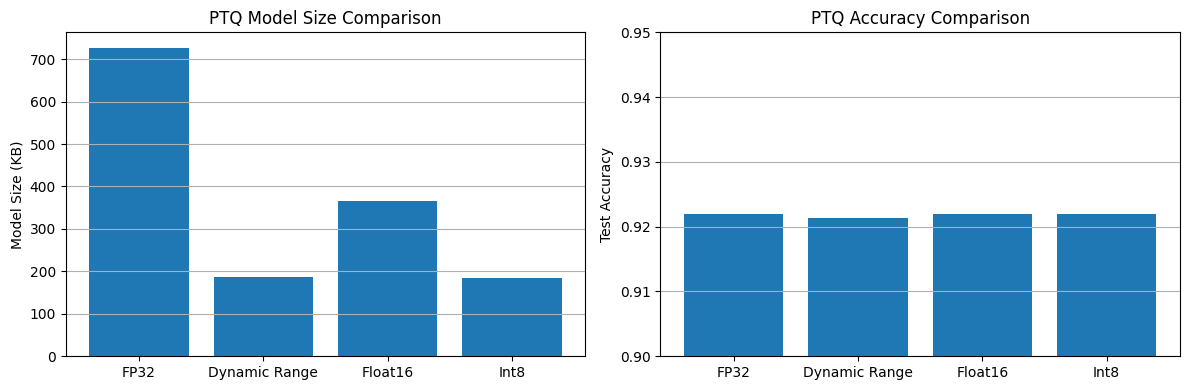

In [32]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(ptq_results["Format"], ptq_results["Model Size (KB)"])
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("PTQ Model Size Comparison")
axes[0].grid(axis="y")

axes[1].bar(ptq_results["Format"], ptq_results["Test Accuracy"])
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("PTQ Accuracy Comparison")
axes[1].set_ylim(0.90, 0.95)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


In [33]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)
qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
qat_model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer_1 (Quantize  (None, 561)               3         
 Layer)                                                          
                                                                 
 quant_dense_8 (QuantizeWra  (None, 256)               143877    
 pperV2)                                                         
                                                                 
 quant_dense_9 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_10 (QuantizeWr  (None, 64)                8261      
 apperV2)                                                        
                                                                 
 quant_dense_11 (QuantizeWr  (None, 6)                

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [34]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)
qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

qat_history = qat_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)

Epoch 1/8
92/92 [==============================] - 1s 4ms/step - loss: 0.0453 - accuracy: 0.9850 - val_loss: 0.1297 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0365 - accuracy: 0.9888 - val_loss: 0.1328 - val_accuracy: 0.9483
Epoch 3/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0363 - accuracy: 0.9874 - val_loss: 0.1416 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0327 - accuracy: 0.9884 - val_loss: 0.1319 - val_accuracy: 0.9456
Epoch 5/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0318 - accuracy: 0.9893 - val_loss: 0.1688 - val_accuracy: 0.9422
Epoch 6/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0316 - accuracy: 0.9884 - val_loss: 0.1545 - val_accuracy: 0.9463
Epoch 7/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0315 - accuracy: 0.9895 - val_loss: 0.1364 - val_accuracy: 0.9483
Epoch 8/8
92/92 [==========

### Fine-Tune the QAT Model


In [35]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

qat_probs = qat_model.predict(X_test)
qat_preds = np.argmax(qat_probs, axis=1)
qat_acc   = accuracy_score(y_test, qat_preds)

print(f"QAT Keras Test Accuracy: {qat_acc:.4f}\n")
print(classification_report(y_test, qat_preds, target_names=class_names, digits=4))


93/93 [==============================] - 0s 1ms/step
QAT Keras Test Accuracy: 0.9321

                    precision    recall  f1-score   support

           WALKING     0.9200    0.9738    0.9461       496
  WALKING_UPSTAIRS     0.9443    0.9002    0.9217       471
WALKING_DOWNSTAIRS     0.9447    0.9357    0.9402       420
           SITTING     0.9698    0.8493    0.9055       491
          STANDING     0.8425    0.9756    0.9042       532
            LAYING     1.0000    0.9516    0.9752       537

          accuracy                         0.9321      2947
         macro avg     0.9369    0.9310    0.9322      2947
      weighted avg     0.9363    0.9321    0.9323      2947



### Evaluate the QAT Keras Model


In [43]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

qat_probs = qat_model.predict(X_test)
qat_preds = np.argmax(qat_probs, axis=1)
qat_acc   = accuracy_score(y_test, qat_preds)

print(f"QAT Keras Test Accuracy: {qat_acc:.4f}\n")
print(classification_report(y_test, qat_preds, target_names=class_names, digits=4))

93/93 [==============================] - 0s 943us/step
QAT Keras Test Accuracy: 0.9321

                    precision    recall  f1-score   support

           WALKING     0.9200    0.9738    0.9461       496
  WALKING_UPSTAIRS     0.9443    0.9002    0.9217       471
WALKING_DOWNSTAIRS     0.9447    0.9357    0.9402       420
           SITTING     0.9698    0.8493    0.9055       491
          STANDING     0.8425    0.9756    0.9042       532
            LAYING     1.0000    0.9516    0.9752       537

          accuracy                         0.9321      2947
         macro avg     0.9369    0.9310    0.9322      2947
      weighted avg     0.9363    0.9321    0.9323      2947



### Convert the QAT Model to Int8 TensorFlow Lite|


In [44]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

qat_int8_tflite = convert_to_tflite_int8(qat_model)
qat_int8_size_kb = save_binary_model(qat_int8_tflite, "qat_int8.tflite")
qat_int8_acc, qat_int8_preds = evaluate_tflite_model(qat_int8_tflite, X_test, y_test)

print(f"QAT Int8 Test Accuracy: {qat_int8_acc:.4f}")
print(f"QAT Int8 Model Size:    {qat_int8_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpccw7zlfr/assets


INFO:tensorflow:Assets written to: /tmp/tmpccw7zlfr/assets


QAT Int8 Test Accuracy: 0.9318
QAT Int8 Model Size:    185.79 KB


/home/sam/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 05:10:26.127296: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 05:10:26.127322: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 05:10:26.127419: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpccw7zlfr
2026-04-23 05:10:26.129113: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 05:10:26.129126: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpccw7zlfr
2026-04-23 05:10:26.134621: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 05:10:26.173851: I tensorflow/cc/saved_model/loader.c

## 12. PTQ Int8 vs QAT Int8


In [39]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

comparison = pd.DataFrame([
    ["PTQ Int8", int8_acc,     int8_size_kb],
    ["QAT Int8", qat_int8_acc, qat_int8_size_kb],
], columns=["Model", "Test Accuracy", "Model Size (KB)"])

print(comparison.to_string(index=False))

   Model  Test Accuracy  Model Size (KB)
PTQ Int8       0.921955       185.390625
QAT Int8       0.931795       185.789062


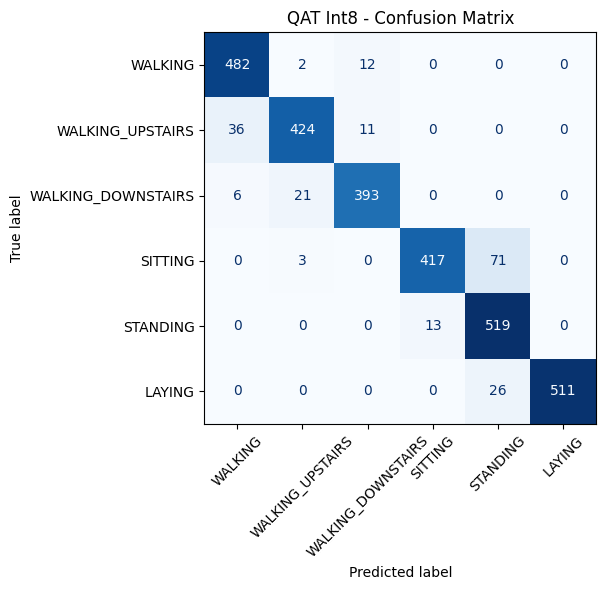

In [40]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, qat_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("QAT Int8 - Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?  **<br>Int8 PTQ at 185.42 KB**
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?  **<br>QAT Int8 at 0.9318 vs PTQ Int8 at 0.9226**
3. Did QAT improve the final int8 model compared with PTQ int8?  **<br>Yes**
4. Why is this dataset a good fit for a DNN-based TinyML workflow?  **<br>Because the input is 561 pre-engineered features with no spatial or temporal structiure.**
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?  **<br>QAT Int8, because it has the best accuracy at a small size, also int8 run efficiently on embedded hardware.**

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
